In [1]:
import os.path
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import os, time, json, math
from typing import List, Any, Tuple
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [2]:
LABEL_COL = 'Cancer_lbl'
ID_COL    = 'pid'

FEATURES_STLMD  = ['sct_long_dia','part_solid','ground_glass','solid','Upper_Lobe','Spiculation','age','sex', 'growth_speed_pct']

# ≥ cutpoints for binning (age & size)
CUTS_CONT = {
    "age": [55, 56, 57, 58, 59, 61, 64, 67],
    "sct_long_dia": [6, 10, 20, 30],
    "growth_speed_pct": [-200, -100, -50, -20, 0, 20, 50, 100, 200],
}

# binary passthroughs (copied as-is)
BIN_PASSTHROUGH_STLMD  = ['part_solid','ground_glass','solid','Upper_Lobe','Spiculation','sex']

# Data files
CSV1 = 'ml_dataset/nlst_ct_nodule_df_set1.csv'
CSV2 = 'ml_dataset/nlst_ct_nodule_df_set2.csv'

def filter_age_le_70(df):
    return df[df['age'] <= 70]

In [3]:
def _norm_text(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    s = re.sub(r'\s+', ' ', s)
    s = s.replace('_','-').replace('–','-').replace('—','-')
    return s

def normalize_and_encode(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Canonicalize gender to {'male','female'}
    - Canonicalize Nodule_Type to {'solid','ground-glass','part-solid'} using common aliases
    - Create binaries: sex, part_solid, ground_glass, solid
    - Coerce Upper_Lobe/Spiculation to ints if present
    - Drop rows with unmapped gender/Nodule_Type; warn on non-exclusive types
    """
    df = df.copy()

    # gender
    g = df['gender'].apply(_norm_text)
    df['gender'] = g.map({'male':'male','m':'male','female':'female','f':'female'})

    # nodule type
    t = df['Nodule_Type'].apply(_norm_text)
    mapping = {
        'solid':'solid', 'sld':'solid',

        'ground-glass':'ground-glass', 'ground glass':'ground-glass',
        'ggo':'ground-glass', 'non-solid':'ground-glass',
        'non solid':'ground-glass', 'nonsolid':'ground-glass',

        'part-solid':'part-solid', 'part solid':'part-solid',
        'semi-solid':'part-solid', 'semisolid':'part-solid', 'subsolid':'part-solid',
    }
    df['Nodule_Type'] = t.map(mapping)

    # drop unmapped
    bad = df['gender'].isna() | df['Nodule_Type'].isna()
    if bad.any():
        print(f"[filter] Dropping {int(bad.sum())} rows with unmapped gender or Nodule_Type")
        # Uncomment to inspect:
        # print(df.loc[bad, [ID_COL,'gender','Nodule_Type']].head(10))
        df = df.loc[~bad].copy()

    # binaries
    df['sex']          = df['gender'].map({'male':0, 'female':1}).astype(int)
    df['part_solid']   = (df['Nodule_Type'] == 'part-solid').astype(int)
    df['ground_glass'] = (df['Nodule_Type'] == 'ground-glass').astype(int)
    df['solid']        = (df['Nodule_Type'] == 'solid').astype(int)

    # passthrough ints
    for b in ['Upper_Lobe','Spiculation']:
        if b in df.columns:
            df[b] = pd.to_numeric(df[b], errors='ignore')
            df[b] = pd.to_numeric(df[b], errors='coerce').fillna(0).astype(int)

    # sanity: exactly one nodule type flag
    onehot_sum = df[['solid','ground_glass','part_solid']].sum(axis=1)
    if (onehot_sum != 1).any():
        print(f"[warn] {int((onehot_sum != 1).sum())} rows have non-exclusive nodule types; please inspect.")

    return df

def to_fastrisk_y(y_raw, pos_label=1) -> np.ndarray:
    """Return 1-D np.ndarray[float] with labels in {-1.0, +1.0}."""
    y_arr = np.asarray(y_raw).ravel()
    uniq = set(np.unique(y_arr))
    if uniq <= {0, 1}:
        return (2 * y_arr - 1).astype(float)
    return np.where(y_arr == pos_label, 1.0, -1.0).astype(float)

def make_ge_bins(df: pd.DataFrame, feature: str, cuts: list[float]) -> pd.DataFrame:
    """
    Build columns like 'age >= 73' or 'sct_long_dia >= 20' (ASCII >=)
    """
    out = pd.DataFrame(index=df.index)
    vals = pd.to_numeric(df[feature], errors='coerce')
    for c in cuts:
        col = f"{feature} >= {c:g}"
        out[col] = (vals >= float(c)).astype(int)
    return out

def build_binary_matrix(X_df: pd.DataFrame,
                        feature_cuts: dict[str, list[float]],
                        passthrough_binary: list[str]) -> pd.DataFrame:
    mats = []
    for feat, cuts in feature_cuts.items():
        if feat not in X_df.columns:
            raise KeyError(f"Missing feature for binning: {feat}")
        mats.append(make_ge_bins(X_df, feat, cuts))
    for feat in passthrough_binary:
        if feat not in X_df.columns:
            raise KeyError(f"Missing binary feature: {feat}")
        col = pd.Series(pd.to_numeric(X_df[feat], errors='coerce')).fillna(0).astype(int)
        mats.append(pd.DataFrame({feat: col}, index=X_df.index))
    return pd.concat(mats, axis=1)

def binarize_and_align_custom(X_train_df: pd.DataFrame,
                              X_val_df: pd.DataFrame,
                              X_test_df: pd.DataFrame,
                              feature_cuts: dict[str, list[float]],
                              passthrough_binary: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Binarize each split with ≥ cuts, then align val/test to training columns.
    """
    X_train_bin = build_binary_matrix(X_train_df, feature_cuts, passthrough_binary)
    X_val_bin   = build_binary_matrix(X_val_df,   feature_cuts, passthrough_binary)
    X_test_bin  = build_binary_matrix(X_test_df,  feature_cuts, passthrough_binary)

    def _align_like_train(train_bin_df: pd.DataFrame, other_bin_df: pd.DataFrame) -> pd.DataFrame:
        cols = list(train_bin_df.columns)
        return other_bin_df.reindex(columns=cols, fill_value=0)

    X_val_bin  = _align_like_train(X_train_bin, X_val_bin)
    X_test_bin = _align_like_train(X_train_bin, X_test_bin)

    # sanity
    assert list(X_val_bin.columns)  == list(X_train_bin.columns)
    assert list(X_test_bin.columns) == list(X_train_bin.columns)
    return X_train_bin, X_val_bin, X_test_bin

def prepare_data(df: pd.DataFrame, feature_cols: list[str], label_col: str):
    X = df[feature_cols]
    y = df[label_col]
    return X, y

## feature engineering

In [4]:
def add_growth_speed(df):
    """
    输入：df，包含pid和sct_long_dia两列
    输出：增加一列growth_speed，表示每个pid内sct_long_dia的增长速度（当前行减去上一行），首行填0
    """
    df = df.copy()
    df['growth_speed'] = df.groupby('pid')['sct_long_dia'].diff().fillna(0)
    return df


In [5]:
def add_growth_speed_pct(df):
    """
    输入：df，包含pid和sct_long_dia两列
    输出：增加一列growth_speed_pct，表示每个pid内sct_long_dia的百分比增长速度，首行填0
    """
    df = df.copy()
    df['growth_speed_pct'] = df.groupby('pid')['sct_long_dia'].transform(
        lambda x: (x.pct_change() * 100).fillna(0)
    )
    return df

In [6]:
def add_screen_flags(df: "pd.DataFrame", pid_col: str = "pid"):
    """Add binary features 1st_screen and 2nd_screen by patient group order."""

    out = df.copy()
    order = out.groupby(pid_col).cumcount()
    out["1st_screen"] = (order == 0).astype(int)
    out["2nd_screen"] = (order == 1).astype(int)
    return out

In [7]:
def add_screening_order(df):
    """
    为dataframe添加screening_order列，按pid分组后逐行编号（从1开始）
    """
    df_new = df.copy()
    df_new['screening_order'] = df_new.groupby('pid').cumcount() + 1
    return df_new

## start analyzing

In [8]:
df1 = pd.read_csv(CSV1)
df2 = pd.read_csv(CSV2)

df1 = filter_age_le_70(df1)
df2 = filter_age_le_70(df2)

df1 = add_growth_speed(df1)
df2 = add_growth_speed(df2)

df1 = add_growth_speed_pct(df1)
df2 = add_growth_speed_pct(df2)

df1 = add_screen_flags(df1, pid_col="pid")
df2 = add_screen_flags(df2, pid_col="pid")

df1 = add_screening_order(df1)
df2 = add_screening_order(df2)

df1 = normalize_and_encode(df1)
df2 = normalize_and_encode(df2)

In [9]:
patients = df1[[ID_COL, LABEL_COL]].drop_duplicates()
train_patients, val_patients = train_test_split(
    patients,
    test_size=0.2,
    stratify=patients[LABEL_COL],
    random_state=42
)
train_df = df1[df1[ID_COL].isin(train_patients[ID_COL])]
val_df   = df1[df1[ID_COL].isin(val_patients[ID_COL])]

# ============================================================
# STLMD (includes age & sex)  —  bins: age >= c, sct_long_dia >= c
# ============================================================
X_train_STLMD_df, y_train_STLMD_raw = prepare_data(train_df, FEATURES_STLMD, LABEL_COL)
X_val_STLMD_df,   y_val_STLMD_raw   = prepare_data(val_df,   FEATURES_STLMD, LABEL_COL)
X_test_STLMD_df,  y_test_STLMD_raw  = prepare_data(df2,      FEATURES_STLMD, LABEL_COL)

X_train_STLMD_bin, X_val_STLMD_bin, X_test_STLMD_bin = binarize_and_align_custom(
    X_train_STLMD_df, X_val_STLMD_df, X_test_STLMD_df,
    feature_cuts={"age": CUTS_CONT["age"], "sct_long_dia": CUTS_CONT["sct_long_dia"], "growth_speed_pct": CUTS_CONT["growth_speed_pct"]},
    passthrough_binary=BIN_PASSTHROUGH_STLMD
)

y_train_STLMD = to_fastrisk_y(y_train_STLMD_raw, pos_label=1)
y_val_STLMD   = to_fastrisk_y(y_val_STLMD_raw,   pos_label=1)
y_test_STLMD  = to_fastrisk_y(y_test_STLMD_raw,  pos_label=1)

X_train_STLMD = X_train_STLMD_bin.to_numpy(dtype=float)
X_val_STLMD   = X_val_STLMD_bin.to_numpy(dtype=float)
X_test_STLMD  = X_test_STLMD_bin.to_numpy(dtype=float)

## Histogram

In [10]:
import matplotlib.pyplot as plt

def plot_histogram(df: "pd.DataFrame", col_name: str, bins: int = 30, figsize=(6, 4), x_range=None):
    """
    Plot a histogram for a specified column in df.
    """
    if col_name not in df.columns:
        raise ValueError(f"Column '{col_name}' not found in DataFrame.")

    series = df[col_name].dropna()
    
    # 如果指定了x_range，则过滤数据
    if x_range is not None:
        series = series[(series >= x_range[0]) & (series <= x_range[1])]
    
    plt.figure(figsize=figsize)
    plt.hist(series, bins=bins, edgecolor="black")
    plt.title(f"Histogram of {col_name}")
    plt.xlabel(col_name)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

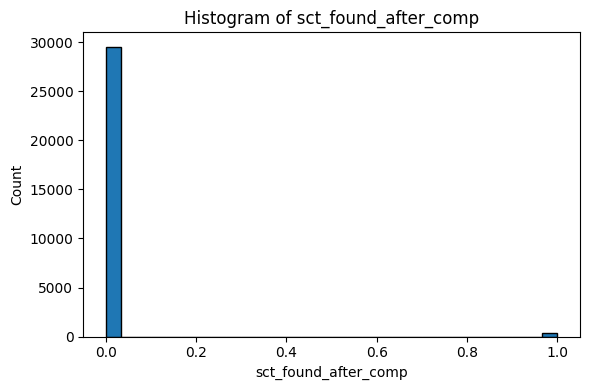

In [14]:
plot_histogram(df1, "sct_found_after_comp")

In [12]:
df1_posi = df1[df1['Cancer_lbl']==1]
df1_nega = df1[df1['Cancer_lbl']==0]

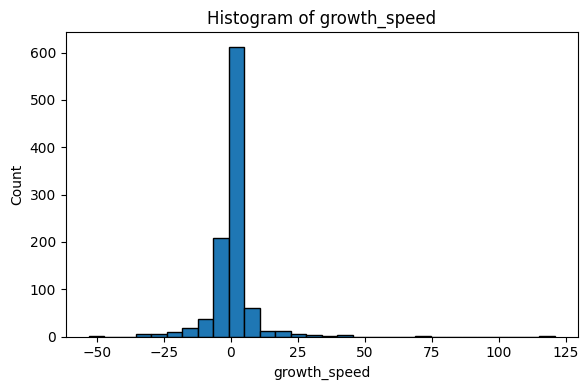

In [13]:
plot_histogram(df1_posi, "growth_speed")

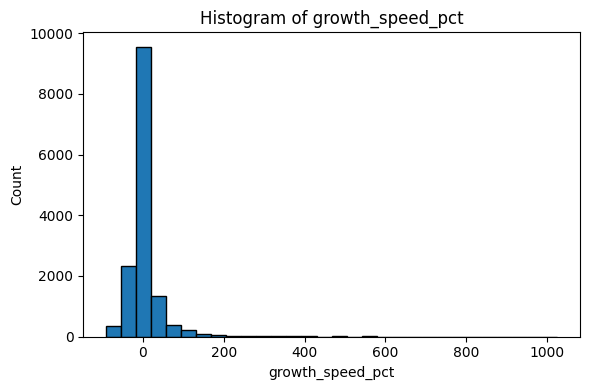

In [14]:
plot_histogram(df1_nega, "growth_speed_pct")

## single feature ROC

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_feature_roc(df: "pd.DataFrame", col_name: str, y_col: str = "Cancer_lbl"):
    """Plot ROC curve using a single feature column as the score."""
    if y_col not in df.columns:
        raise ValueError(f"y column '{y_col}' not found in DataFrame.")
    if col_name not in df.columns:
        raise ValueError(f"Column '{col_name}' not found in DataFrame.")

    y_true = df[y_col]
    y_score = df[col_name]

    mask = y_true.notna() & y_score.notna()
    y_true = y_true[mask]
    y_score = y_score[mask]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {col_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

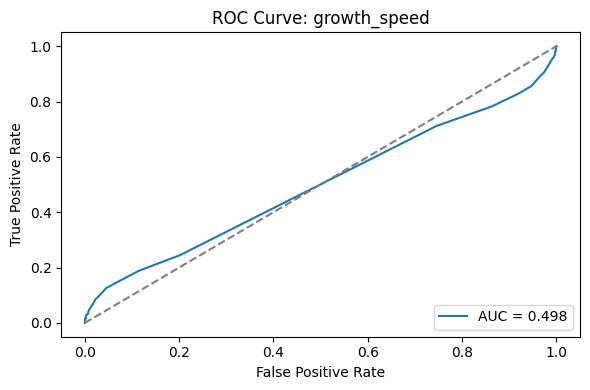

In [16]:
plot_feature_roc(df1, "growth_speed")

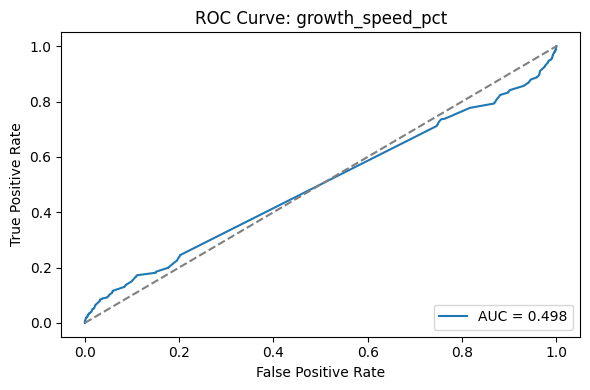

In [17]:
plot_feature_roc(df1, "growth_speed_pct")

wired: growth speed and growth speed pct show no prediction power

maybe because most of them is near 0

## 筛选数据：只保留第一次得cancer的数据行

In [18]:
def first_cancer_rows(df1):
    """Return first row per pid where Cancer_lbl == 1."""
    cancer_rows = df1[df1["Cancer_lbl"] == 1]
    return cancer_rows.groupby("pid", sort=False, as_index=False).head(1)


In [19]:
df1_first_cancer = first_cancer_rows(df1)
df1_first_cancer

,pid,study_yr,age,gender,all_sct_set,sct_long_dia,sct_margins,sct_pre_att,sct_epi_loc,can_scr,...,Cancer_lbl,growth_speed,growth_speed_pct,1st_screen,2nd_screen,screening_order,sex,part_solid,ground_glass,solid
48,100158,2,65.0,male,1.0,12.0,Smooth,Soft Tissue,Right Upper Lobe,Positive Screen,...,1,0.0,0.0,1,0,1,0,0,0,1
63,100280,1,60.0,female,1.0,10.0,Unable to determine,Soft Tissue,Left Lower Lobe,Positive Screen,...,1,0.0,0.0,1,0,1,1,0,0,1
123,100570,0,63.0,male,1.0,22.0,Spiculated (Stellate),Soft Tissue,Lingula,Positive Screen,...,1,0.0,0.0,1,0,1,0,0,0,1
125,100580,0,70.0,male,1.0,6.0,Smooth,Soft Tissue,Lingula,Post Screening,...,1,0.0,0.0,1,0,1,0,0,0,1
357,101068,0,66.0,male,1.0,6.0,Poorly defined,Soft Tissue,Right Upper Lobe,Positive Screen,...,1,0.0,0.0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16199,217465,1,65.0,female,1.0,6.0,Smooth,Soft Tissue,Lingula,Post Screening,...,1,0.0,0.0,1,0,1,1,0,0,1
16338,218013,1,58.0,female,1.0,9.0,Smooth,Soft Tissue,Right Upper Lobe,Positive Screen,...,1,0.0,0.0,1,0,1,1,0,0,1
16355,218044,2,60.0,female,1.0,4.0,Poorly defined,Soft Tissue,Left Upper Lobe,Post Screening,...,1,0.0,0.0,1,0,1,1,0,0,1
16518,218499,0,63.0,male,1.0,12.0,Spiculated (Stellate),Mixed,Right Upper Lobe,Post Screening,...,1,0.0,0.0,1,0,1,0,1,0,0


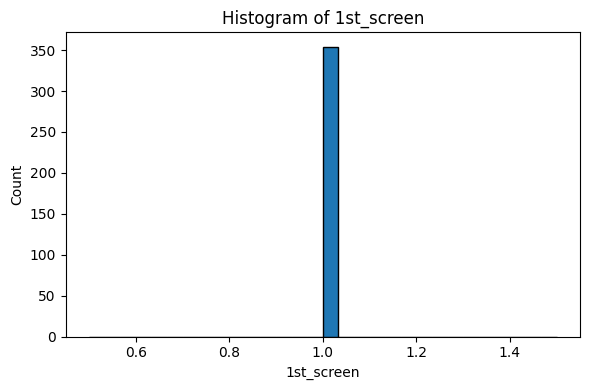

In [20]:
plot_histogram(df1_first_cancer, "1st_screen")

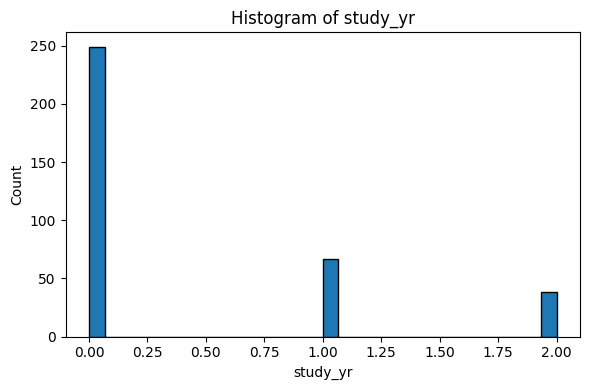

In [21]:
plot_histogram(df1_first_cancer, "study_yr")

### something wrong with the data: for certain patients, there only contains the data with study year bigger than 2. Some data is missing. Guess: the data before finding the cancer is missing

If this is the case, then the feature 1st screening will be useless.

## 探索：第一次得癌症的人的其他特征

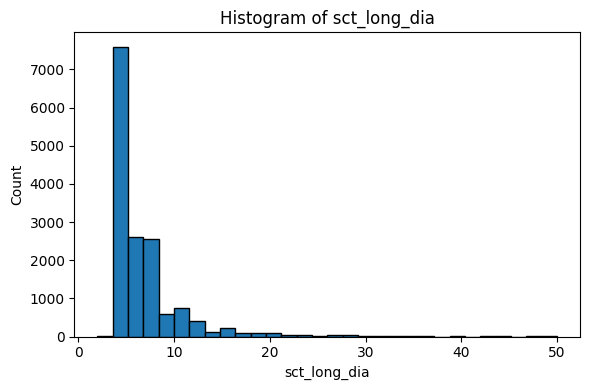

In [22]:
plot_histogram(df1, 'sct_long_dia', x_range=[0, 50])

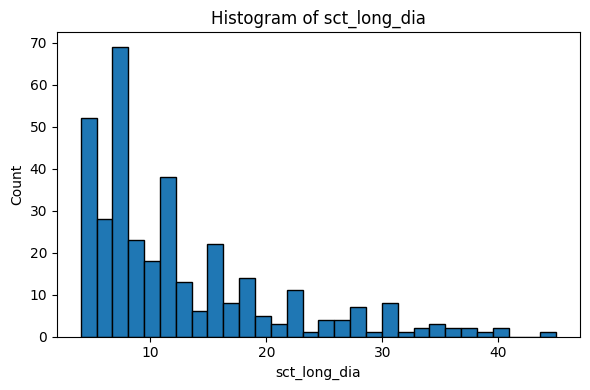

In [23]:
plot_histogram(df1_first_cancer, 'sct_long_dia', x_range=[0, 50])

In [24]:
def compare_feature_means(df1, df2, feature_name):
    """
    比较两个DataFrame中某个特征的平均值
    """
    mean1 = df1[feature_name].mean()
    mean2 = df2[feature_name].mean()
    difference = mean1 - mean2
    
    print(f"特征: {feature_name}")
    print(f"DataFrame 1 的平均值: {mean1:.4f}")
    print(f"DataFrame 2 的平均值: {mean2:.4f}")
    print(f"平均值差值 (df1 - df2): {difference:.4f}")
    
    return mean1, mean2, difference

In [25]:
compare_feature_means(df1_first_cancer, df1, "sex")

特征: sex
DataFrame 1 的平均值: 0.4181
DataFrame 2 的平均值: 0.4260
平均值差值 (df1 - df2): -0.0080


(0.4180790960451977, 0.4260293544616184, -0.007950258416420664)

## 散点图

画散点图：x轴为age，y轴为第几次screening。点的深浅代表多少比例的是阳的。

In [26]:
def plot_scatter_with_cancer_ratio(df, x_feature, y_feature, figsize=(10, 6), x_range=None, y_range=None):
    """
    画散点图，点的颜色深度代表Cancer_lbl为1的比例
    """
    # 复制df，然后根据x_range和y_range过滤
    df_filtered = df.copy()
    
    if x_range is not None:
        df_filtered = df_filtered[(df_filtered[x_feature] >= x_range[0]) & (df_filtered[x_feature] <= x_range[1])]
    
    if y_range is not None:
        df_filtered = df_filtered[(df_filtered[y_feature] >= y_range[0]) & (df_filtered[y_feature] <= y_range[1])]
    
    # 按x_feature和y_feature分组，计算Cancer_lbl为1的比例
    grouped = df_filtered.groupby([x_feature, y_feature])['Cancer_lbl'].agg(['sum', 'count']).reset_index()
    grouped['cancer_ratio'] = grouped['sum'] / grouped['count']
    
    # 创建散点图
    plt.figure(figsize=figsize)
    scatter = plt.scatter(grouped[x_feature], grouped[y_feature], 
                         c=grouped['cancer_ratio'],  # 颜色由Cancer_lbl比例决定
                         cmap='YlOrRd',  # 使用YlOrRd颜色映射（黄->橙->红）
                         s=50,  # 点的大小
                         alpha=0.7,  # 透明度
                         edgecolors='black',  # 边界颜色
                         linewidth=0.5)
    
    # 添加颜色条
    cbar = plt.colorbar(scatter)
    cbar.set_label('Cancer proportion', fontsize=10)
    
    # 添加标签和标题
    plt.xlabel(x_feature, fontsize=12)
    plt.ylabel(y_feature, fontsize=12)
    plt.title(f'{x_feature} vs {y_feature}', fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

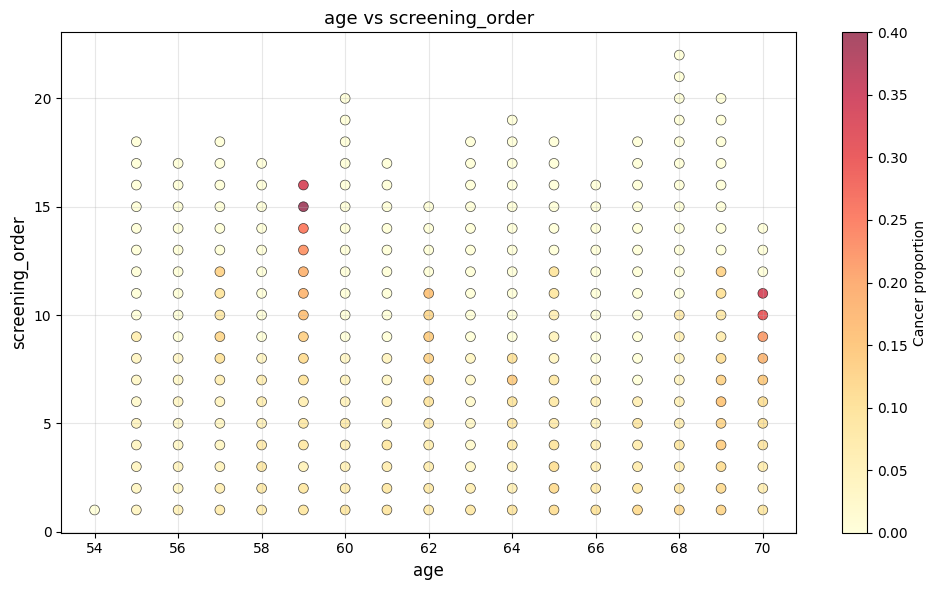

In [27]:
plot_scatter_with_cancer_ratio(df1, 'age', 'screening_order')

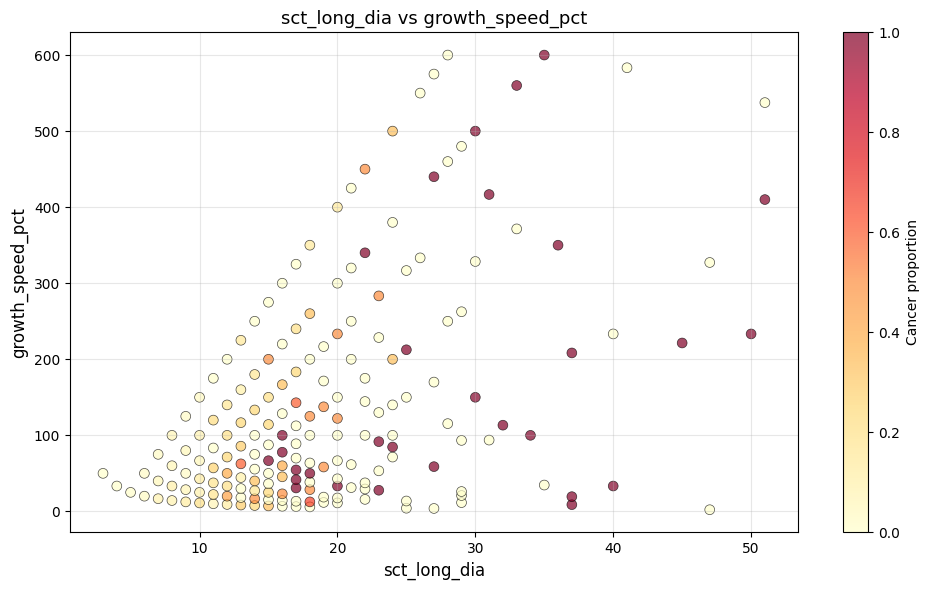

In [28]:
plot_scatter_with_cancer_ratio(df1, 'sct_long_dia', 'growth_speed_pct', x_range=[0,60], y_range=[0.1,600])

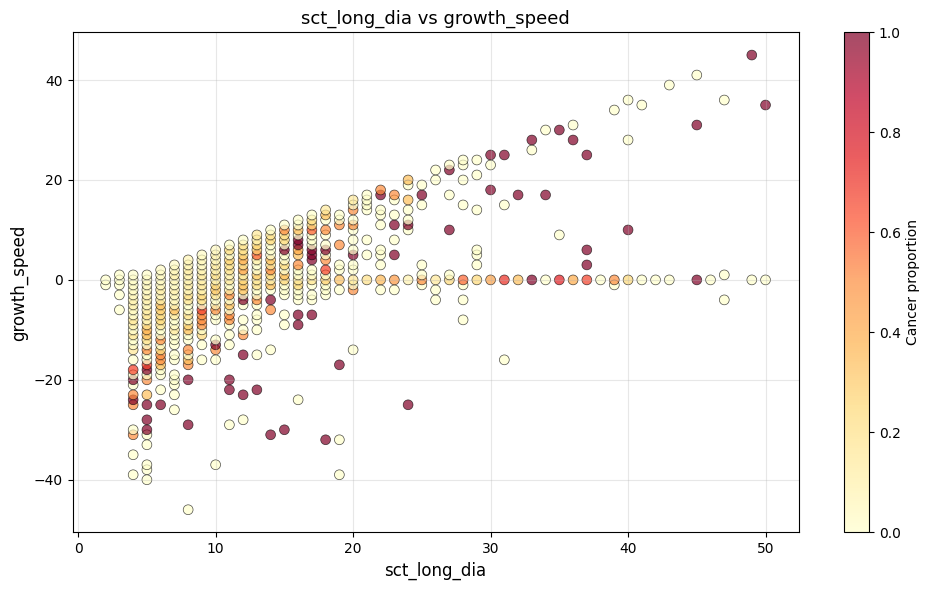

In [29]:
plot_scatter_with_cancer_ratio(df1, 'sct_long_dia', 'growth_speed', x_range=[0,50], y_range=[-50,50])